# Exploracao de Dados - Passos Mágicos

Análise exploratória do dataset PEDE para previsão de risco de defasagem escolar.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Carregamento dos Dados


In [3]:
DATA_PATH = '../../dados-datathon/DATATHON/Bases antigas/PEDE_PASSOS_DATASET_FIAP.csv'

df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8')

print(f"Shape: {df.shape}")
print(f"Registros: {df.shape[0]:,}")
print(f"Features: {df.shape[1]}")


Shape: (1349, 69)
Registros: 1,349
Features: 69


In [4]:
df.head()


,INSTITUICAO_ENSINO_ALUNO_2020,NOME,IDADE_ALUNO_2020,ANOS_PM_2020,FASE_TURMA_2020,PONTO_VIRADA_2020,INDE_2020,INDE_CONCEITO_2020,PEDRA_2020,DESTAQUE_IEG_2020,DESTAQUE_IDA_2020,DESTAQUE_IPV_2020,IAA_2020,IEG_2020,IPS_2020,IDA_2020,IPP_2020,IPV_2020,IAN_2020,FASE_2021,TURMA_2021,INSTITUICAO_ENSINO_ALUNO_2021,SINALIZADOR_INGRESSANTE_2021,PEDRA_2021,INDE_2021,IAA_2021,IEG_2021,IPS_2021,IDA_2021,IPP_2021,REC_EQUIPE_1_2021,REC_EQUIPE_2_2021,REC_EQUIPE_3_2021,REC_EQUIPE_4_2021,PONTO_VIRADA_2021,IPV_2021,IAN_2021,NIVEL_IDEAL_2021,DEFASAGEM_2021,FASE_2022,TURMA_2022,ANO_INGRESSO_2022,BOLSISTA_2022,INDE_2022,CG_2022,CF_2022,CT_2022,PEDRA_2022,DESTAQUE_IEG_2022,DESTAQUE_IDA_2022,DESTAQUE_IPV_2022,IAA_2022,IEG_2022,IPS_2022,IDA_2022,NOTA_PORT_2022,NOTA_MAT_2022,NOTA_ING_2022,QTD_AVAL_2022,IPP_2022,REC_AVA_1_2022,REC_AVA_2_2022,REC_AVA_3_2022,REC_AVA_4_2022,INDICADO_BOLSA_2022,PONTO_VIRADA_2022,IPV_2022,IAN_2022,NIVEL_IDEAL_2022
0,Escola Pública,ALUNO-1,11,2,2H,Não,7.883752,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,Ponto a melhorar em 2021: Empenhar-se mais nas...,Seu destaque em 2020: A sua boa integração aos...,8.500020000000001,8.7,7.5,7,5.9375,7.75,10,2.0,G,Rede Decisão,Ingressante,Ametista,7.319,7.5,6.3,6.9,8.8,7.7,Promovido de Fase,Promovido de Fase,Mantido na Fase atual,Não avaliado,Não,8.1,5.0,Nível 3 (7o e 8o ano),-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,ALUNO-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,K,2022.0,Não,7.675509,245.0,66.0,6.0,Ametista,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Destaque: A sua boa integração aos Princípios ...,10.00002,7.581705,7.5,8.816667,8.200000,9.433333,NaN,2.0,5.625000,Mantido na Fase + Bolsa,Mantido na Fase atual,NaN,NaN,Sim,Não,7.916665,5.0,Fase 2 (5º e 6º ano)
2,Escola Pública,ALUNO-3,12,2,3H,Não,7.856389666666666,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,Ponto a melhorar em 2021: Empenhar-se mais nas...,Seu destaque em 2020: A sua boa integração aos...,7.91667,8.9,7.5,5.5,8.125,8.111113333333334,10,3.0,F,Escola Pública,Veterano,Ametista,7.021,7.1,6.9,6.3,5.6,7.3,Promovido de Fase,Promovido de Fase,Mantido na Fase atual,Não avaliado,Não,7.2,10.0,Nível 3 (7o e 8o ano),0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Escola Pública,ALUNO-4,10,2,1D,Não,5.076252,D,Quartzo,Ponto a melhorar em 2021: Melhorar a sua entre...,Ponto a melhorar em 2021: Empenhar-se mais nas...,Ponto a melhorar em 2021: Integrar-se mais aos...,8.000020000000001,4.1,6.875,0,7.1875,7.75,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,J,2022.0,Não,7.117065,451.0,69.0,3.0,Ametista,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,10.00002,8.071429,7.5,5.083333,5.000000,5.166667,NaN,3.0,6.250000,Promovido de Fase,Mantido na Fase atual,Promovido de Fase,NaN,Não,Não,8.055553,5.0,Fase 3 (7º e 8º ano)
4,Escola Pública,ALUNO-5,10,1,2M,Não,8.077085,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,Seu destaque em 2020: As suas boas notas na Pa...,Seu destaque em 2020: A sua boa integração aos...,7.50002,8,7.5,7.5,8.4375,8.166665,10,2.0,L,Escola Pública,Veterano,Ametista,7.399,7.4,7.5,7.5,5.4,8.5,Promovido de Fase,Mantido na Fase atual,Mantido na Fase atual,Não avaliado,Não,7.4,10.0,Nível 2 (5o e 6o ano),0.0,2.0,L,2019.0,Não,7.232336,415.0,61.0,12.0,Ametista,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,6.41668,8.557505,7.5,7.083333,6.666667,7.500000,NaN,3.0,6.458333,Mantido na Fase atual,Promovido de Fase,Mantido na Fase atual

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   INSTITUICAO_ENSINO_ALUNO_2020  728 non-null    object 
 1   NOME                           1349 non-null   object 
 2   IDADE_ALUNO_2020               728 non-null    object 
 3   ANOS_PM_2020                   728 non-null    object 
 4   FASE_TURMA_2020                728 non-null    object 
 5   PONTO_VIRADA_2020              702 non-null    object 
 6   INDE_2020                      728 non-null    object 
 7   INDE_CONCEITO_2020             728 non-null    object 
 8   PEDRA_2020                     728 non-null    object 
 9   DESTAQUE_IEG_2020              728 non-null    object 
 10  DESTAQUE_IDA_2020              728 non-null    object 
 11  DESTAQUE_IPV_2020              703 non-null    object 
 12  IAA_2020                       728 non-null    o

## 2. Análise da Variável Target


In [6]:
print("Distribuição de DEFASAGEM_2021:")
print(df['DEFASAGEM_2021'].value_counts(dropna=False).sort_index())
print(f"\nMissing: {df['DEFASAGEM_2021'].isna().sum()} ({df['DEFASAGEM_2021'].isna().sum()/len(df)*100:.1f}%)")


Distribuição de DEFASAGEM_2021:
DEFASAGEM_2021
-4.0      2
-3.0      8
-2.0     93
-1.0    317
 0.0    249
 1.0     16
 3.0      1
 NaN    663
Name: count, dtype: int64

Missing: 663 (49.1%)


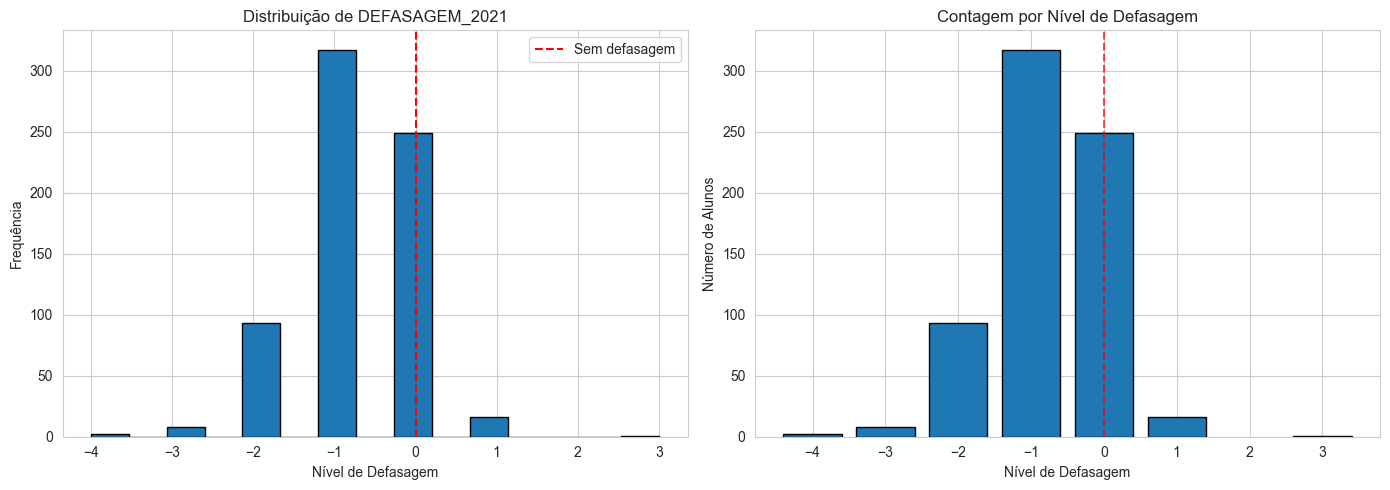

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['DEFASAGEM_2021'].dropna().hist(bins=15, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribuição de DEFASAGEM_2021')
axes[0].set_xlabel('Nível de Defasagem')
axes[0].set_ylabel('Frequência')
axes[0].axvline(0, color='red', linestyle='--', label='Sem defasagem')
axes[0].legend()

defasagem_counts = df['DEFASAGEM_2021'].value_counts().sort_index()
axes[1].bar(defasagem_counts.index, defasagem_counts.values, edgecolor='black')
axes[1].set_title('Contagem por Nível de Defasagem')
axes[1].set_xlabel('Nível de Defasagem')
axes[1].set_ylabel('Número de Alunos')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Criar Target Binário


In [8]:
df['RISCO_DEFASAGEM'] = (df['DEFASAGEM_2021'] < 0).astype(int)

print("Target Binário - RISCO_DEFASAGEM:")
print(df['RISCO_DEFASAGEM'].value_counts())
print(f"\nProporção de alunos em risco: {df['RISCO_DEFASAGEM'].mean()*100:.1f}%")

fig = px.pie(
    values=df['RISCO_DEFASAGEM'].value_counts().values,
    names=['Adequado', 'Em Risco'],
    title='Distribuição de Risco de Defasagem',
    color_discrete_sequence=['#2ecc71', '#e74c3c']
)
fig.show()


Target Binário - RISCO_DEFASAGEM:
RISCO_DEFASAGEM
0    929
1    420
Name: count, dtype: int64

Proporção de alunos em risco: 31.1%


## 3. Análise de Missing Values


In [9]:
missing_df = pd.DataFrame({
    'coluna': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing_df = missing_df[missing_df['missing_pct'] > 0]

print(f"Colunas com valores ausentes: {len(missing_df)} de {len(df.columns)}")
print("\nTop 20 colunas com mais missings:")
print(missing_df.head(20))


Colunas com valores ausentes: 68 de 70

Top 20 colunas com mais missings:
                                                      coluna  missing_count  \
REC_AVA_4_2022                                REC_AVA_4_2022           1064   
NOTA_ING_2022                                  NOTA_ING_2022           1064   
REC_AVA_3_2022                                REC_AVA_3_2022            723   
IPV_2021                                            IPV_2021            663   
REC_EQUIPE_1_2021                          REC_EQUIPE_1_2021            663   
PEDRA_2021                                        PEDRA_2021            663   
SINALIZADOR_INGRESSANTE_2021    SINALIZADOR_INGRESSANTE_2021            663   
INSTITUICAO_ENSINO_ALUNO_2021  INSTITUICAO_ENSINO_ALUNO_2021            663   
TURMA_2021                                        TURMA_2021            663   
FASE_2021                                          FASE_2021            663   
IEG_2021                                            IEG_2

In [10]:
fig = px.bar(
    missing_df.head(20),
    x='missing_pct',
    y='coluna',
    orientation='h',
    title='Top 20 Features com Valores Ausentes',
    labels={'missing_pct': '% Missing', 'coluna': 'Feature'},
    color='missing_pct',
    color_continuous_scale='Reds'
)
fig.update_layout(height=600)
fig.show()


### Converter colunas numéricas


In [11]:
colunas_numericas = [
    'IDADE_ALUNO_2020', 'ANOS_PM_2020', 'INDE_2020', 'IAA_2020', 'IEG_2020', 
    'IPS_2020', 'IDA_2020', 'IPP_2020', 'IPV_2020', 'IAN_2020',
    'INDE_2021', 'IAA_2021', 'IEG_2021', 'IPS_2021', 'IDA_2021', 'IPP_2021', 
    'IPV_2021', 'IAN_2021', 'DEFASAGEM_2021',
    'INDE_2022', 'IAA_2022', 'IEG_2022', 'IPS_2022', 'IDA_2022', 'IPP_2022', 
    'IPV_2022', 'IAN_2022', 'NOTA_PORT_2022', 'NOTA_MAT_2022', 'NOTA_ING_2022',
    'CG_2022', 'CF_2022', 'CT_2022', 'QTD_AVAL_2022', 'ANO_INGRESSO_2022'
]

for col in colunas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Colunas convertidas para numérico")


Colunas convertidas para numérico


## 4. Análise dos Indicadores 2020


In [12]:
indicadores_2020 = ['INDE_2020', 'IAA_2020', 'IEG_2020', 'IPS_2020', 
                     'IDA_2020', 'IPP_2020', 'IPV_2020', 'IAN_2020']

print("Estatisticas dos Indicadores 2020:")
df[indicadores_2020].describe().T


Estatisticas dos Indicadores 2020:


,count,mean,std,min,25%,50%,75%,max
INDE_2020,727.0,7.296111,1.199925,3.065002,6.569584,7.580834,8.178960,9.712504
IAA_2020,727.0,8.368882,1.727980,0.000000,7.958350,8.750010,9.166680,10.000020
IEG_2020,727.0,7.681155,2.382122,0.000000,6.600000,8.500000,9.500000,10.000000
IPS_2020,727.0,6.737448,1.374011,2.500000,5.625000,7.500000,7.500000,10.000000
IDA_2020,727.0,6.322260,2.960073,0.000000,4.666667,7.000000,8.666667,10.000000
IPP_2020,727.0,7.067859,1.988054,0.000000,6.953125,7.500000,8.125000,10.000000
IPV_2020,727.0,7.242243,1.775110,0.000000,6.916665,7.583335,8.055557,10.000010
IAN_2020,727.0,7.431224,2.556944,2.500000,5.000000,5.000000,10.000000,10.000000


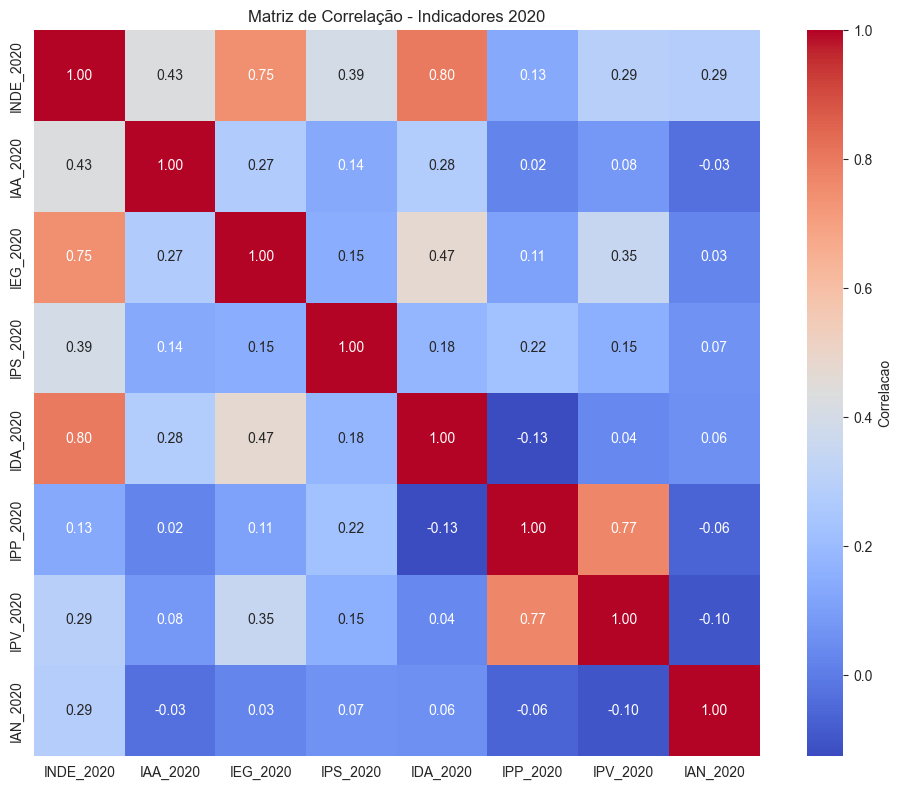

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[indicadores_2020].corr(), 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm',
    square=True,
    cbar_kws={'label': 'Correlacao'}
)
plt.title('Matriz de Correlação - Indicadores 2020')
plt.tight_layout()
plt.show()


## 5. Relação entre Indicadores 2020 e Risco 2021


In [14]:
df_analise = df[df['RISCO_DEFASAGEM'].notna()].copy()

print(f"Registros para análise: {len(df_analise):,}")
print(f"Em risco: {df_analise['RISCO_DEFASAGEM'].sum():,}")
print(f"Adequado: {(df_analise['RISCO_DEFASAGEM'] == 0).sum():,}")


Registros para análise: 1,349
Em risco: 420
Adequado: 929


In [15]:
comparacao = df_analise.groupby('RISCO_DEFASAGEM')[indicadores_2020].mean().T
comparacao.columns = ['Adequado', 'Em Risco']
comparacao['Diferenca'] = comparacao['Adequado'] - comparacao['Em Risco']

print("Média dos Indicadores 2020 por Grupo de Risco:")
comparacao.round(3)


Média dos Indicadores 2020 por Grupo de Risco:


,Adequado,Em Risco,Diferenca
INDE_2020,7.251,7.367,-0.116
IAA_2020,8.230,8.588,-0.359
IEG_2020,7.387,8.145,-0.758
IPS_2020,6.788,6.658,0.130
IDA_2020,5.993,6.842,-0.849
IPP_2020,7.091,7.032,0.059
IPV_2020,7.118,7.439,-0.321
IAN_2020,7.994,6.543,1.452


In [16]:
fig = px.bar(
    comparacao.reset_index(),
    x='index',
    y=['Adequado', 'Em Risco'],
    barmode='group',
    title='Comparação de Indicadores 2020 por Risco de Defasagem 2021',
    labels={'index': 'Indicador', 'value': 'Média'},
    color_discrete_sequence=['#2ecc71', '#e74c3c']
)
fig.update_layout(height=500)
fig.show()


## 6. Análise por PEDRA (Classificação)


In [17]:
print("Distribuição de PEDRA 2020:")
print(df['PEDRA_2020'].value_counts())

risco_por_pedra = df_analise.groupby('PEDRA_2020')['RISCO_DEFASAGEM'].agg(['mean', 'count'])
risco_por_pedra.columns = ['Taxa_Risco', 'Quantidade']
risco_por_pedra['Taxa_Risco'] = (risco_por_pedra['Taxa_Risco'] * 100).round(2)

print("\nTaxa de Risco por Classificação PEDRA:")
risco_por_pedra.sort_values('Taxa_Risco', ascending=False)


Distribuição de PEDRA 2020:
PEDRA_2020
Ametista    336
Ágata       171
Quartzo     128
Topázio      92
D9891/2A      1
Name: count, dtype: int64

Taxa de Risco por Classificação PEDRA:


,Taxa_Risco,Quantidade
PEDRA_2020,,
Ametista,44.35,336
Ágata,40.94,171
Quartzo,28.91,128
Topázio,28.26,92
D9891/2A,0.00,1


## 7. Features Categóricas


In [18]:
print("Taxa de Risco por Instituição de Ensino (2020):")
risco_instituicao = df_analise.groupby('INSTITUICAO_ENSINO_ALUNO_2020')['RISCO_DEFASAGEM'].agg(['mean', 'count'])
risco_instituicao.columns = ['Taxa_Risco_%', 'Quantidade']
risco_instituicao['Taxa_Risco_%'] = (risco_instituicao['Taxa_Risco_%'] * 100).round(2)
print(risco_instituicao.sort_values('Taxa_Risco_%', ascending=False))


Taxa de Risco por Instituição de Ensino (2020):
                               Taxa_Risco_%  Quantidade
INSTITUICAO_ENSINO_ALUNO_2020                          
Escola João Paulo II                 100.00           2
Escola Pública                        42.14         598
Rede Decisão/União                    27.72         101
Einstein                               0.00           2
Estácio                                0.00           3
FIAP                                   0.00          11
UNISA                                  0.00          10
V202                                   0.00           1


In [19]:
print("Taxa de Risco por Ponto de Virada 2020:")
risco_pv = df_analise.groupby('PONTO_VIRADA_2020')['RISCO_DEFASAGEM'].agg(['mean', 'count'])
risco_pv.columns = ['Taxa_Risco_%', 'Quantidade']
risco_pv['Taxa_Risco_%'] = (risco_pv['Taxa_Risco_%'] * 100).round(2)
print(risco_pv)


Taxa de Risco por Ponto de Virada 2020:
                   Taxa_Risco_%  Quantidade
PONTO_VIRADA_2020                          
D9600                      0.00           1
Não                       40.69         607
Sim                       37.23          94


## 8. Análise Temporal e Demográfica


In [20]:
print("Estatísticas de Idade (2020):")
print(df['IDADE_ALUNO_2020'].describe())

df_analise['FAIXA_ETARIA'] = pd.cut(
    df_analise['IDADE_ALUNO_2020'], 
    bins=[0, 10, 13, 16, 100],
    labels=['Ate 10 anos', '11-13 anos', '14-16 anos', 'Mais de 16']
)

print("\nTaxa de Risco por Faixa Etaria:")
risco_idade = df_analise.groupby('FAIXA_ETARIA')['RISCO_DEFASAGEM'].agg(['mean', 'count'])
risco_idade.columns = ['Taxa_Risco_%', 'Quantidade']
risco_idade['Taxa_Risco_%'] = (risco_idade['Taxa_Risco_%'] * 100).round(2)
print(risco_idade)


Estatísticas de Idade (2020):
count    727.000000
mean      12.408528
std        2.829807
min        7.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       20.000000
Name: IDADE_ALUNO_2020, dtype: float64

Taxa de Risco por Faixa Etaria:
              Taxa_Risco_%  Quantidade
FAIXA_ETARIA                          
Ate 10 anos          37.16         218
11-13 anos           49.03         259
14-16 anos           38.64         176
Mais de 16            8.11          74


In [21]:
print("Estatísticas de Anos na Passos Mágicos (2020):")
print(df['ANOS_PM_2020'].describe())

print("\nTaxa de Risco por Tempo na Passos Mágicos:")
risco_tempo = df_analise.groupby('ANOS_PM_2020')['RISCO_DEFASAGEM'].agg(['mean', 'count'])
risco_tempo.columns = ['Taxa_Risco_%', 'Quantidade']
risco_tempo['Taxa_Risco_%'] = (risco_tempo['Taxa_Risco_%'] * 100).round(2)
print(risco_tempo.sort_index())


Estatísticas de Anos na Passos Mágicos (2020):
count    727.000000
mean       1.467675
std        1.131195
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        4.000000
Name: ANOS_PM_2020, dtype: float64

Taxa de Risco por Tempo na Passos Mágicos:
              Taxa_Risco_%  Quantidade
ANOS_PM_2020                          
0.0                  38.81         134
1.0                  40.00         305
2.0                  40.38         156
3.0                  33.33          78
4.0                  35.19          54


## 9. Distribuições dos Indicadores por Grupo de Risco


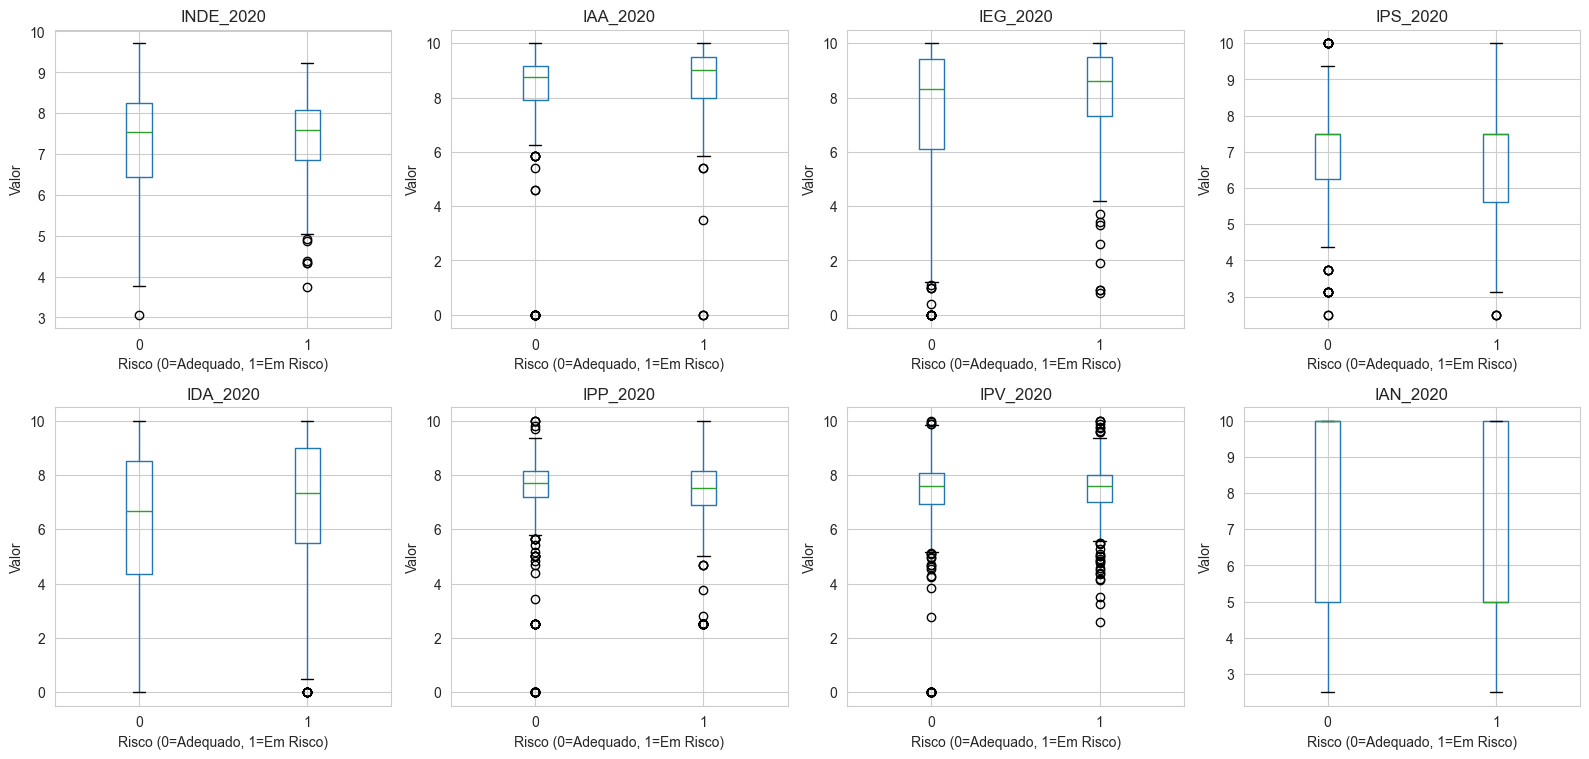

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(indicadores_2020):
    df_analise.boxplot(column=col, by='RISCO_DEFASAGEM', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Risco (0=Adequado, 1=Em Risco)')
    axes[idx].set_ylabel('Valor')

plt.tight_layout()
plt.suptitle('')
plt.show()


## 10. Correlação Features vs Target


In [23]:
correlacoes = df_analise[indicadores_2020 + ['RISCO_DEFASAGEM']].corr()['RISCO_DEFASAGEM'].drop('RISCO_DEFASAGEM').sort_values(ascending=False)

print("Correlação dos Indicadores 2020 com RISCO_DEFASAGEM:")
print(correlacoes)

fig = px.bar(
    x=correlacoes.values,
    y=correlacoes.index,
    orientation='h',
    title='Correlação: Indicadores 2020 vs Risco de Defasagem 2021',
    labels={'x': 'Correlação', 'y': 'Indicador'},
    color=correlacoes.values,
    color_continuous_scale='RdYlGn_r'
)
fig.show()


Correlação dos Indicadores 2020 com RISCO_DEFASAGEM:
IEG_2020     0.155245
IDA_2020     0.139845
IAA_2020     0.101186
IPV_2020     0.088088
INDE_2020    0.047195
IPP_2020    -0.014521
IPS_2020    -0.046177
IAN_2020    -0.276862
Name: RISCO_DEFASAGEM, dtype: float64


## 11. Conclusões Preliminares

### Principais observações:

1. **Dataset:** 1.349 alunos, 69 features (2020-2022)

2. **Target:**
   - 49% de missings (alunos sem dados em 2021)
   - ~61% dos alunos com dados estão em situação de defasagem

3. **Features mais correlacionadas com risco:**
   - IAN (Adequação ao Nível) - correlação negativa forte
   - IDA (Aprendizagem)
   - INDE (Índice agregado)

4. **Desbalanceamento:** Classes desbalanceadas (61% em risco vs 39% adequado)
   - Precisaremos usar tecnicas: SMOTE, class_weight, ou ajuste de threshold

